# Readability Score Analysis Notebook
This notebook builds on the data that exists after running the code in the notebook called 'descriptive stats.ipynb'

### 1. Importing Data
Imports the csv file that was saved at the end of the descriptive_stats notebook. 

NB: If you are using an environment, please remember to choose kernel accordingly

In [24]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import scipy.stats as stats
from scipy.stats import levene, ttest_ind, mannwhitneyu
from nltk.tokenize import word_tokenize, sent_tokenize

# Create output directory
os.makedirs("stat_outputs", exist_ok=True)
os.makedirs("plot_outputs", exist_ok=True)

# Ensure necessary models are available
nltk.download('punkt')

# Load dataset
df_all = pd.read_csv("df_desc_filt.csv", encoding="utf-8", low_memory=False)


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/nannasteenholdt/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### 2. Readability Index Score Analysis (LIX)

The higher the score, the more difficult the text is to read

In [25]:
def calculate_lix(text):
    if not isinstance(text, str) or not text.strip():
        return np.nan
    words = word_tokenize(text)
    words = [w for w in words if w.isalpha()]
    long_words = [w for w in words if len(w) > 6]
    sentences = sent_tokenize(text, language="danish")
    num_sentences = max(len(sentences), 1)
    if len(words) == 0:
        return np.nan
    return (len(words) / num_sentences) + (100 * len(long_words) / len(words))

df_rs = df_all.copy()
df_rs["summary_PostingCreated"] = pd.to_datetime(df_rs["summary_PostingCreated"], errors="coerce")
df_rs["Posting_Year"] = df_rs["summary_PostingCreated"].dt.year
df_rs["Period_Group"] = df_rs["Posting_Year"].apply(lambda x: "2022" if x == 2022 else ("2024/2025" if x in [2024, 2025] else None))
df_rs_grouped = df_rs[df_rs["Period_Group"].notnull()].copy()
df_rs_grouped["lix"] = df_rs_grouped["details_JobPositionPosting_JobPositionInformation_Purpose"].apply(calculate_lix)
df_rs_grouped = df_rs_grouped[df_rs_grouped["lix"].between(0, 100)]

# Save summary stats
summary_stats = df_rs_grouped.groupby("Period_Group")["lix"].describe()
summary_stats.to_csv("stat_outputs/lix_summary_stats.csv")
print(summary_stats)

                count       mean       std        min        25%        50%  \
Period_Group                                                                  
2022          14574.0  49.882159  8.578853  21.011204  44.351725  49.491212   
2024/2025     10041.0  50.465854  8.019917  17.968407  45.171374  49.924643   

                    75%        max  
Period_Group                        
2022          54.784588  98.714286  
2024/2025     54.872847  99.006803  


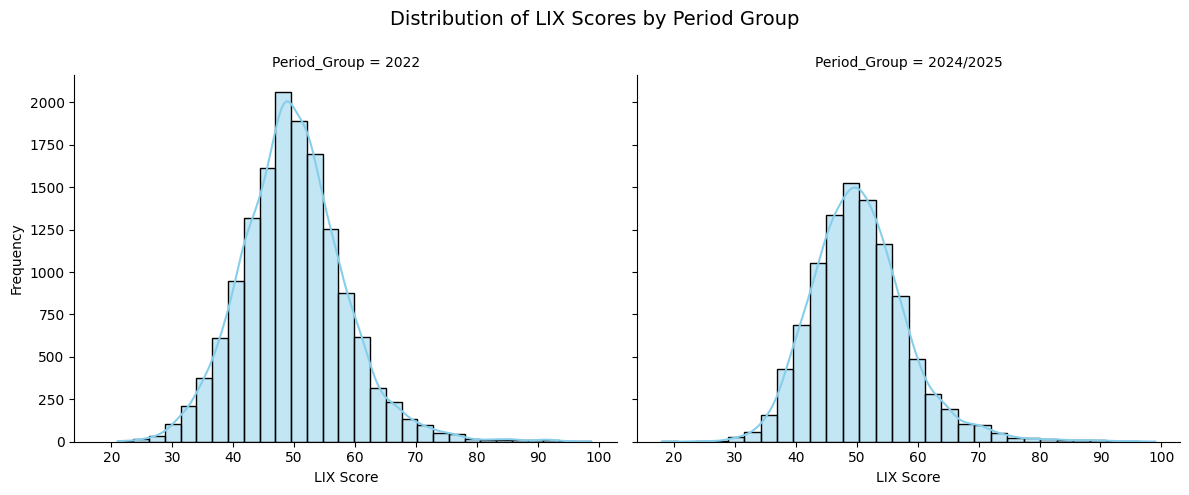

Plot saved to 'plot_outputs/lix_score_distribution_by_period_group.png'


In [26]:
# Faceted histogram
g = sns.FacetGrid(df_rs_grouped, col="Period_Group", col_order=["2022", "2024/2025"],
                  height=5, aspect=1.2, sharex=True, sharey=True)
g.map(sns.histplot, "lix", bins=30, kde=True, color="skyblue")
g.set_axis_labels("LIX Score", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Distribution of LIX Scores by Period Group", fontsize=14)

path_hist = os.path.join("plot_outputs", "lix_score_distribution_by_period_group.png")
plt.savefig(path_hist, dpi=300)
plt.show()
print(f"Plot saved to '{path_hist}'")

### Q-Q Plots

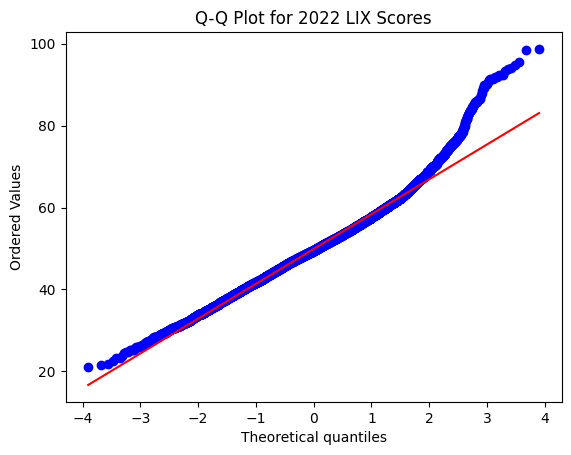

Saved Q-Q plot: plot_outputs/qqplot_2022_raw.png


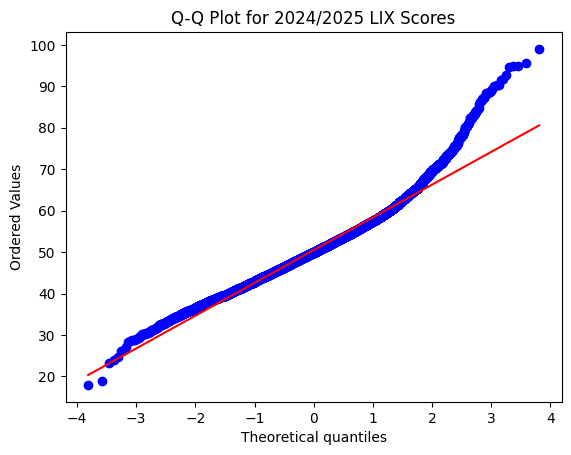

Saved Q-Q plot: plot_outputs/qqplot_2024_2025_raw.png


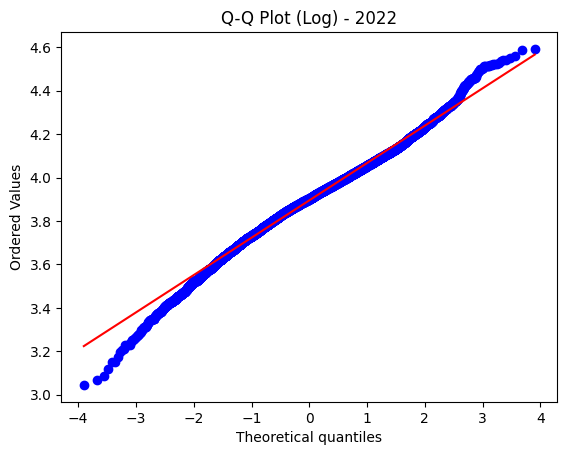

Saved Q-Q plot: plot_outputs/qqplot_2022_log.png


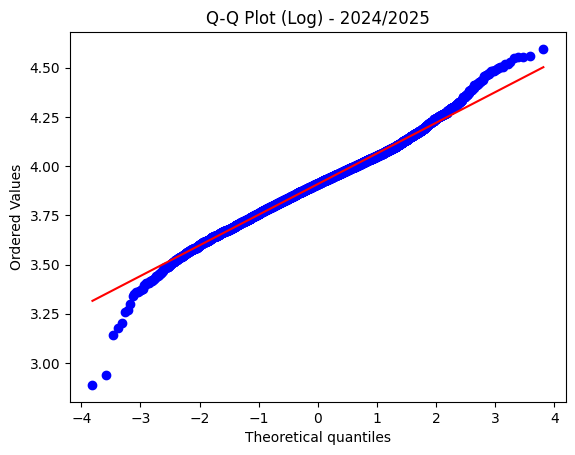

Saved Q-Q plot: plot_outputs/qqplot_2024_2025_log.png


In [27]:
group_2022 = df_rs_grouped[df_rs_grouped["Period_Group"] == "2022"]["lix"].dropna()
group_2024_2025 = df_rs_grouped[df_rs_grouped["Period_Group"] == "2024/2025"]["lix"].dropna()

def save_qqplot(data, title, filename, log=False):
    plt.figure()
    stats.probplot(np.log(data) if log else data, dist="norm", plot=plt)
    plt.title(title)
    path = os.path.join("plot_outputs", filename)
    plt.savefig(path, dpi=300)
    plt.show()
    print(f"Saved Q-Q plot: {path}")

save_qqplot(group_2022, "Q-Q Plot for 2022 LIX Scores", "qqplot_2022_raw.png")
save_qqplot(group_2024_2025, "Q-Q Plot for 2024/2025 LIX Scores", "qqplot_2024_2025_raw.png")
save_qqplot(group_2022, "Q-Q Plot (Log) - 2022", "qqplot_2022_log.png", log=True)
save_qqplot(group_2024_2025, "Q-Q Plot (Log) - 2024/2025", "qqplot_2024_2025_log.png", log=True)


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_74189/981261238.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


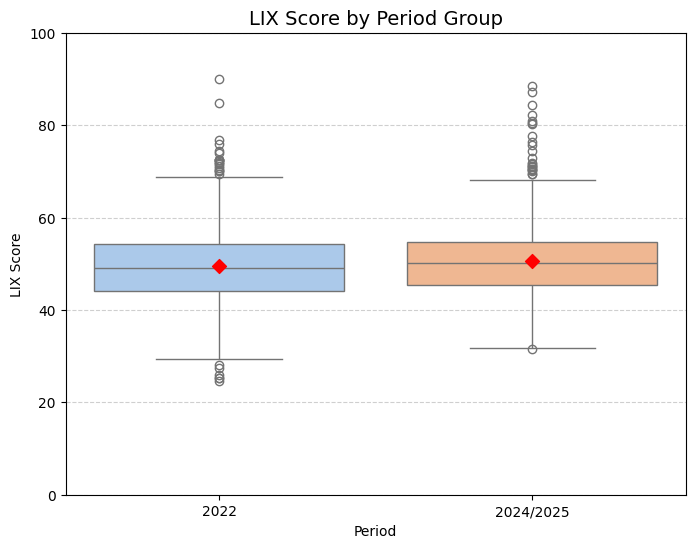

Boxplot saved to: plot_outputs/lix_score_boxplot_by_period_group.png


In [35]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_rs_grouped,
    x='Period_Group',
    y='lix',
    order=["2022", "2024/2025"],
    palette='pastel'
)
plt.grid(axis='y', linestyle='--', alpha=0.6)

means = df_rs_grouped.groupby("Period_Group")["lix"].mean()
for i, period in enumerate(["2022", "2024/2025"]):
    plt.scatter(i, means[period], color='red', zorder=10, marker='D', s=50)

plt.title("LIX Score by Period Group", fontsize=14)
plt.xlabel("Period")
plt.ylabel("LIX Score")
plt.ylim(0, 100)

boxplot_path = os.path.join("plot_outputs", "lix_score_boxplot_by_period_group.png")
plt.savefig(boxplot_path, dpi=300)
plt.show()
print(f"Boxplot saved to: {boxplot_path}")

### 4. Statistical Testing

### Levene's Test

Using Levene's test for checking homogeneity of variance between the two groups/periods

In [28]:
# Results storage
Levene_results = []

# Levene’s Test
Levene_results.append("Levene’s Test:")
stat, p_value = levene(group_2022, group_2024_2025)
Levene_results.append(f"Raw: stat = {stat:.3f}, p = {p_value:.4f}")

# Levene’s Test on log-transformed data
stat, p_value = levene(np.log(group_2022), np.log(group_2024_2025))
Levene_results.append(f"Log: stat = {stat:.3f}, p = {p_value:.4f}")

print("\n".join(Levene_results))

Levene’s Test:
Raw: stat = 43.671, p = 0.0000
Log: stat = 74.586, p = 0.0000


### Welsch's T-test

Using Welsch's T-test for comparing groups

In [29]:
Welch_results = []

# Welch’s T-test
Welch_results.append("\nWelch’s T-test:")
stat, p_value = ttest_ind(group_2022, group_2024_2025, equal_var=False)
Welch_results.append(f"Raw: stat = {stat:.3f}, p = {p_value:.4f}")
# Log-transformed Welch’s T-test
stat, p_value = ttest_ind(np.log(group_2022), np.log(group_2024_2025), equal_var=False)
Welch_results.append(f"Log: stat = {stat:.3f}, p = {p_value:.4f}")

print("\n".join(Welch_results))


Welch’s T-test:
Raw: stat = -5.454, p = 0.0000
Log: stat = -6.677, p = 0.0000


### Cohen's D (Effect Size)

I use Cohen's D to determine the effect size

This block will output both results for both the raw and log-transformed data

In [30]:
Cohen_results = []

# Cohen’s d
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx-1)*x.std(ddof=1)**2 + (ny-1)*y.std(ddof=1)**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_std

Cohen_results.append("\nCohen's d:")
d_raw = cohens_d(group_2024_2025, group_2022)
d_log = cohens_d(np.log(group_2024_2025), np.log(group_2022))
Cohen_results.append(f"Raw: d = {d_raw:.3f}")
Cohen_results.append(f"Log: d = {d_log:.3f}")

# Print and save results
for line in Cohen_results:
    print(line)

with open("stat_outputs/lix_stats_results.txt", "w", encoding="utf-8") as f:
    for line in Cohen_results:
        f.write(line + "\n")

print("Results saved to 'stat_outputs/lix_stats_results.txt'")



Cohen's d:
Raw: d = 0.070
Log: d = 0.085
Results saved to 'stat_outputs/lix_stats_results.txt'


### Robustness Check

I run a Mann-Whitney U test as a robustness check

In [33]:
MWU_results = []

# Mann–Whitney U Test
MWU_results.append("\nMann–Whitney U Test:")
stat, p_value = mannwhitneyu(group_2022, group_2024_2025, alternative="two-sided")
MWU_results.append(f"Raw: U = {stat}, p = {p_value:.4f}")

# Mann–Whitney U Test with log transformation
stat, p_value = mannwhitneyu(np.log(group_2022), np.log(group_2024_2025), alternative="two-sided")
MWU_results.append(f"Log: U = {stat}, p = {p_value:.4f}")

print("\n".join(MWU_results))



Mann–Whitney U Test:
Raw: U = 70604359.5, p = 0.0000
Log: U = 70604361.0, p = 0.0000
